# **SISTEMAS DE  VISION 317**
# **PRÁCTICA #4: Detección de líneas y círculos.**
**Jose Antonio Martinez Calan 2127803**

IMPORTAR LIBRERÍAS

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

FUNCIÓN PARA MOSTRAR IMÁGENES

In [9]:
def mostrar_imagen(titulo, imagen, tamaño=5):
    """
    Función personalizada para mostrar imágenes
    """
    if imagen is None:
        print(f"Error: La imagen para '{titulo}' es None")
        return
    plt.figure(figsize=(tamaño, tamaño))
    if len(imagen.shape) == 3:
        # Convertir BGR a RGB para mostrar correctamente los colores
        imagen_mostrar = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        plt.imshow(imagen_mostrar)
    else:
        plt.imshow(imagen, cmap='gray')
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


CARGAR IMAGEN ORIGINAL

 CARGANDO IMAGEN ....
Imagen 'Figuras.png' cargada exitosamente


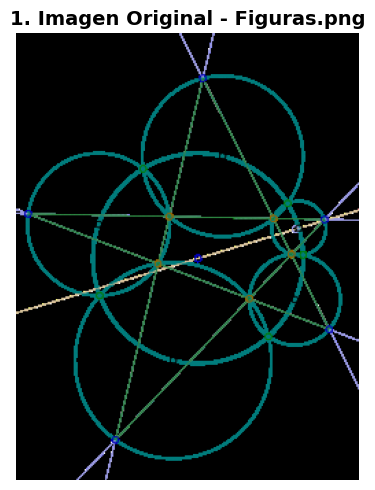

In [10]:
print(" CARGANDO IMAGEN ....")
imagen_original = cv2.imread('Figuras.png')
if imagen_original is None:
    print("Error: No se pudo cargar 'Figuras.png'")
else:
    print("Imagen 'Figuras.png' cargada exitosamente")
# Mostrar imagen original
mostrar_imagen("1. Imagen Original - Figuras.png", imagen_original)

PREPROCESAMIENTO, DETECCIÓN DE BORDES


 DETECCIÓN DE BORDES 


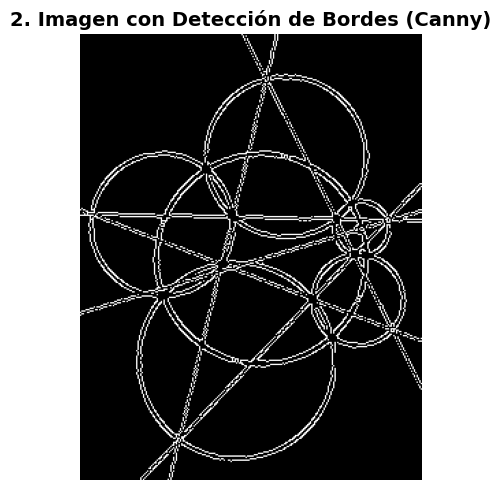

In [11]:
print("\n DETECCIÓN DE BORDES ")
# Convertir a escala de grises
gris = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2GRAY)
# Aplicar filtro Canny para detección de bordes
bordes = cv2.Canny(gris, 50, 150, apertureSize=3)
# Mostrar imagen con bordes
mostrar_imagen("2. Imagen con Detección de Bordes (Canny)", bordes)

DETECCIÓN DE LÍNEAS CON HOUGH


 DETECCIÓN DE LÍNEAS 
Se detectaron 9 líneas


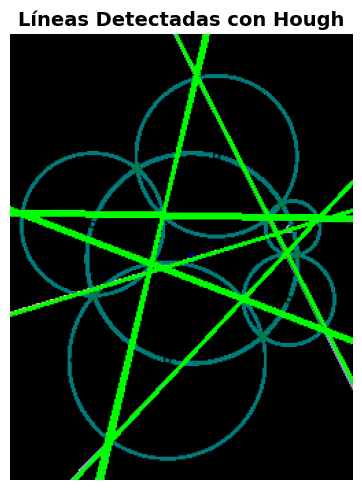

In [12]:
print("\n DETECCIÓN DE LÍNEAS ")
# Crear una copia de la imagen original para dibujar las líneas
imagen_con_lineas = imagen_original.copy()
# Detectar líneas usando Transformada de Hough
lineas = cv2.HoughLines(bordes, 1, np.pi/180, threshold=120)
# Verificar si se detectaron líneas
if lineas is not None:
    print(f"Se detectaron {len(lineas)} líneas")
    # Dibujar las líneas detectadas
    for linea in lineas:
        rho, theta = linea[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        # Calcular puntos extremos de la línea
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        # Dibujar línea en color verde
        cv2.line(imagen_con_lineas, (x1, y1), (x2, y2), (0, 255, 0), 2)
else:
    print("No se detectaron líneas")
    # Intentar con umbral más bajo
    lineas = cv2.HoughLines(bordes, 1, np.pi/180, threshold=80)
    if lineas is not None:
        print(f"✅ Se detectaron {len(lineas)} líneas con umbral más bajo")
        for linea in lineas:
            rho, theta = linea[0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(imagen_con_lineas, (x1, y1), (x2, y2), (0, 255, 0), 2)
# Mostrar imagen con líneas detectadas
mostrar_imagen("Líneas Detectadas con Hough", imagen_con_lineas)

 DETECCIÓN DE CÍRCULOS CON HOUGH


 DETECCIÓN DE CÍRCULOS 
 Se detectaron 29 círculos
   ○ Centro: (133, 164), Radio: 78
   ○ Centro: (116, 238), Radio: 72
   ○ Centro: (151, 89), Radio: 57
   ○ Centro: (58, 137), Radio: 51
   ○ Centro: (201, 194), Radio: 33
   ○ Centro: (143, 111), Radio: 79
   ○ Centro: (131, 224), Radio: 93
   ○ Centro: (112, 217), Radio: 91
   ○ Centro: (146, 185), Radio: 53
   ○ Centro: (127, 143), Radio: 60
   ○ Centro: (171, 127), Radio: 56
   ○ Centro: (119, 179), Radio: 58
   ○ Centro: (65, 157), Radio: 69
   ○ Centro: (149, 148), Radio: 52
   ○ Centro: (169, 177), Radio: 37
   ○ Centro: (133, 254), Radio: 49
   ○ Centro: (89, 157), Radio: 36
   ○ Centro: (97, 248), Radio: 53
   ○ Centro: (206, 141), Radio: 21
   ○ Centro: (133, 76), Radio: 38
   ○ Centro: (175, 147), Radio: 41
   ○ Centro: (43, 151), Radio: 33
   ○ Centro: (139, 205), Radio: 37
   ○ Centro: (166, 76), Radio: 39
   ○ Centro: (100, 193), Radio: 32
   ○ Centro: (45, 121), Radio: 30
   ○ Centro: (89, 130), Radio: 23
   ○ Centro: 

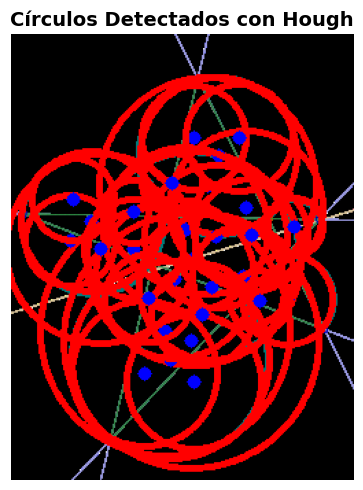

In [13]:
print("\n DETECCIÓN DE CÍRCULOS ")
# Crear una copia para dibujar círculos
imagen_con_circulos = imagen_original.copy()
# Aplicar suavizado para mejorar la detección de círculos
suavizado = cv2.medianBlur(gris, 5)
# Detectar círculos usando Transformada de Hough
circulos = cv2.HoughCircles(
    suavizado,           # Imagen en escala de grises
    cv2.HOUGH_GRADIENT,  # Método de detección
    dp=1.2,              # Razón de acumulador/resolución
    minDist=20,          # Distancia mínima entre centros
    param1=50,           # Umbral alto para Canny
    param2=30,           # Umbral para detección de centro
    minRadius=5,         # Radio mínimo
    maxRadius=100        # Radio máximo
)
# Verificar si se detectaron círculos
if circulos is not None:
    # Convertir coordenadas a enteros
    circulos = np.uint16(np.around(circulos))
    print(f" Se detectaron {len(circulos[0])} círculos")
    # Dibujar círculos detectados
    for circulo in circulos[0, :]:
        centro_x, centro_y, radio = circulo
        # Dibujar círculo exterior (rojo)
        cv2.circle(imagen_con_circulos, (centro_x, centro_y), radio, (0, 0, 255), 3)
        # Dibujar centro del círculo (azul)
        cv2.circle(imagen_con_circulos, (centro_x, centro_y), 2, (255, 0, 0), 5)
        # Mostrar información del círculo
        print(f"   ○ Centro: ({centro_x}, {centro_y}), Radio: {radio}")
else:
    print("No se detectaron círculos")
    # Intentar con parámetros más flexibles
    circulos = cv2.HoughCircles(
        suavizado,
        cv2.HOUGH_GRADIENT,
        dp=1.1,
        minDist=15,
        param1=30,
        param2=25,
        minRadius=3,
        maxRadius=150
    )
    if circulos is not None:
        circulos = np.uint16(np.around(circulos))
        print(f" Se detectaron {len(circulos[0])} círculos con parámetros ajustados")
        for circulo in circulos[0, :]:
            centro_x, centro_y, radio = circulo
            cv2.circle(imagen_con_circulos, (centro_x, centro_y), radio, (0, 0, 255), 3)
            cv2.circle(imagen_con_circulos, (centro_x, centro_y), 2, (255, 0, 0), 5)
# Mostrar imagen con círculos detectados
mostrar_imagen("Círculos Detectados con Hough", imagen_con_circulos)

COMBINAR AMBAS DETECCIONES


=== COMBINANDO DETECCIONES ===


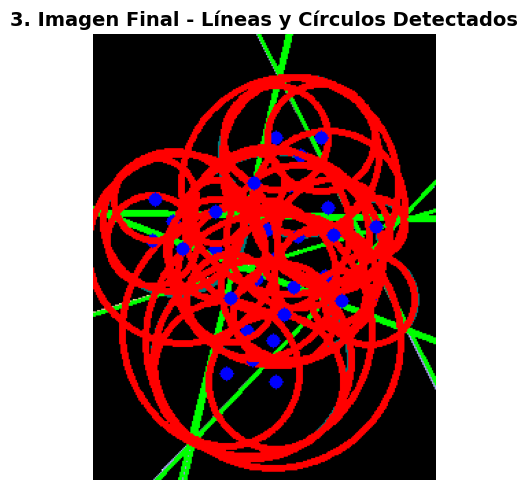

In [14]:
print("\n=== COMBINANDO DETECCIONES ===")
# Crear imagen final con líneas y círculos
imagen_final = imagen_original.copy()
# Dibujar líneas (verdes)
if lineas is not None:
    for linea in lineas:
        rho, theta = linea[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(imagen_final, (x1, y1), (x2, y2), (0, 255, 0), 2)
# Dibujar círculos (rojos con centro azul)
if circulos is not None:
    for circulo in circulos[0, :]:
        centro_x, centro_y, radio = circulo
        cv2.circle(imagen_final, (centro_x, centro_y), radio, (0, 0, 255), 3)
        cv2.circle(imagen_final, (centro_x, centro_y), 2, (255, 0, 0), 5)
# Mostrar imagen final con todas las detecciones
mostrar_imagen("3. Imagen Final - Líneas y Círculos Detectados", imagen_final)
